# Tier 0 · Notebook 2 — Tensors & Tensor-Valued Autograd

> **Goal:** rebuild the autograd engine, but where **one node is a whole array** (a matrix, a batch) instead of a single number. This is what makes real neural nets fast, and it forces us to solve the two things scalars let us dodge: **broadcasting** and the **matrix chain rule** (gradients of `@`).

In Notebook 1 you built scalar reverse-mode autodiff and trained an MLP where every weight was its own `Value`. That's beautiful for understanding — and hopelessly slow. A single `768×768` weight matrix would be ~590k `Value` objects, each doing one Python multiply. Real frameworks put a **tensor** at each node so one operation (`A @ B`) does millions of multiplies in one optimized call.

**What you'll build**
- A `Tensor` class: a NumPy array that records its graph and backprops.
- The one genuinely new idea: **`unbroadcast`** — how a gradient flows back through NumPy broadcasting.
- The **matrix-calculus** backward rules for `@` (`dA = dY·Bᵀ`, `dB = Aᵀ·dY`) — derived, not memorized.
- Softmax **cross-entropy** with its famous `p − y` gradient.
- A `Linear` layer and an MLP, trained on **two interleaving moons** (a nonlinear problem), with the **decision boundary** drawn before vs after training.

**Ground rule:** pure NumPy in the core. PyTorch only at the end, to check our gradients.


## 0. Motivation: why one node should be a whole array

Let's *feel* the speed gap first. We multiply two `N×N` matrices two ways: a hand-written triple loop (what scalar-autograd effectively does) vs one NumPy call (what tensor-autograd does). Same math, wildly different speed — because NumPy dispatches to optimized, vectorized BLAS code instead of a Python-level loop.


In [1]:
import numpy as np
import time

N = 80
A = np.random.randn(N, N)
B = np.random.randn(N, N)

# 1) triple loop — the "scalar" way (Python-level, one multiply at a time)
t0 = time.perf_counter()
C_loop = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        s = 0.0
        for k in range(N):
            s += A[i, k] * B[k, j]
        C_loop[i, j] = s
t_loop = time.perf_counter() - t0

# 2) one vectorized call — the "tensor" way
t0 = time.perf_counter()
C_np = A @ B
t_np = time.perf_counter() - t0

print(f"triple loop : {t_loop*1e3:8.2f} ms")
print(f"numpy  @    : {t_np*1e3:8.4f} ms")
print(f"speedup     : {t_loop/t_np:8.0f}x   (same result: {np.allclose(C_loop, C_np)})")


triple loop :   139.25 ms
numpy  @    :   0.9034 ms
speedup     :      154x   (same result: True)


That speedup (hundreds to thousands×, and it *grows* with size) is the entire reason tensors sit at every node. So our job: make autograd work when `data` is an `ndarray`. Two new problems appear that scalars never had — **broadcasting** and **matmul** — and each needs its own backward rule.


## 1. The `Tensor` class and the shape problem

The skeleton is the same as `Value`: `data`, `grad`, `_backward`, `_prev`. Two differences:

1. `data` is a NumPy array, so `grad` must be an array **of the same shape** (one gradient per element).
2. When an op **broadcasts** (e.g. adding a bias of shape `(4,)` to a batch of shape `(32, 4)`), the forward output is bigger than one of the inputs. On the backward pass the gradient comes back at the *output* shape and must be **reduced back down** to the input's shape. That reduction is the function `unbroadcast` below — the single most important new idea in this notebook.

Why *sum*? Because broadcasting means one input element was *reused* across many output elements. From Notebook 1: reuse ⇒ the multivariate chain rule ⇒ **sum** the gradient contributions. Broadcasting is just reuse along whole axes, so we sum along those axes.


In [2]:
def unbroadcast(grad, shape):
    """Reduce `grad` back to `shape`, reversing NumPy broadcasting by summing
    over the axes that were stretched. This is the backward pass of broadcasting."""
    # (a) NumPy added leading axes to make ranks match -> sum them away
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    # (b) any axis that was size-1 in the input got stretched -> sum it back to size 1
    for axis, size in enumerate(shape):
        if size == 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad

# sanity: bias (4,) added to batch (3,4); upstream grad is ones (3,4).
# Each bias element was reused across the 3 rows, so its grad should be 3.
print(unbroadcast(np.ones((3, 4)), (4,)))     # -> [3. 3. 3. 3.]
print(unbroadcast(np.ones((3, 4)), (1, 4)))   # -> [[3. 3. 3. 3.]]
print(unbroadcast(np.ones((3, 4)), (3, 1)))   # -> [[4.] [4.] [4.]]


[3. 3. 3. 3.]
[[3. 3. 3. 3.]]
[[4.]
 [4.]
 [4.]]


### The engine skeleton + elementwise add

Now the class. `__add__` uses `unbroadcast` on both parents so the gradient always lands at the right shape. Everything elementwise (`+`, `*`) follows this exact pattern.


In [3]:
class Tensor:
    def __init__(self, data, _children=(), _op=''):
        self.data = np.asarray(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)     # same shape as data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    @property
    def shape(self): return self.data.shape

    def __repr__(self): return f"Tensor(shape={self.data.shape}, op={self._op or 'leaf'})"

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), '+')
        def _backward():
            # d(out)/d(self) = 1, then reduce to each parent's shape
            self.grad  += unbroadcast(out.grad, self.data.shape)
            other.grad += unbroadcast(out.grad, other.data.shape)
        out._backward = _backward
        return out


## 2. Visualize broadcasting — forward stretch, backward sum

Let's *see* it. Take `a` of shape `(3,1)` and `b` of shape `(1,4)`; `a + b` broadcasts both to `(3,4)`. On the way back, a gradient of ones at `(3,4)` must collapse: `a` gets summed **along the stretched axis (columns)** → `(3,1)`, and `b` gets summed **along rows** → `(1,4)`. Top row = forward, bottom row = backward.


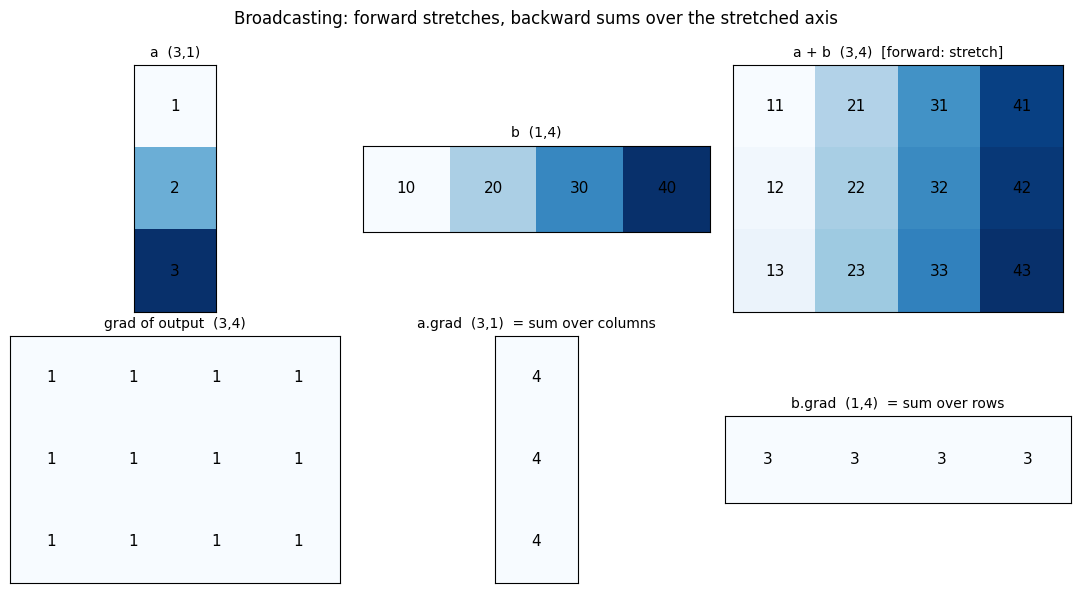

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

def show(ax, M, title):
    M2 = np.atleast_2d(np.asarray(M, dtype=float))
    ax.imshow(M2, cmap="Blues", vmin=M2.min(), vmax=M2.max()+1e-9)
    for (i, j), v in np.ndenumerate(M2):
        ax.text(j, i, f"{v:g}", ha="center", va="center", fontsize=11)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

a = np.array([[1.], [2.], [3.]])          # (3,1)
b = np.array([[10., 20., 30., 40.]])      # (1,4)
out = a + b                                # (3,4)
gout = np.ones((3, 4))                      # upstream grad
ga = unbroadcast(gout, a.shape)            # (3,1) -> each 4
gb = unbroadcast(gout, b.shape)            # (1,4) -> each 3

fig, ax = plt.subplots(2, 3, figsize=(11, 6))
show(ax[0, 0], a,   "a  (3,1)")
show(ax[0, 1], b,   "b  (1,4)")
show(ax[0, 2], out, "a + b  (3,4)  [forward: stretch]")
show(ax[1, 0], gout, "grad of output  (3,4)")
show(ax[1, 1], ga,   "a.grad  (3,1)  = sum over columns")
show(ax[1, 2], gb,   "b.grad  (1,4)  = sum over rows")
fig.suptitle("Broadcasting: forward stretches, backward sums over the stretched axis", fontsize=12)
plt.tight_layout(); plt.show()


`a.grad` is `4` everywhere (each row-value was reused across 4 columns) and `b.grad` is `3` everywhere (each column-value reused across 3 rows). **Reuse → sum.** That's `unbroadcast`, and it's exactly why bias gradients in a network are summed over the batch dimension.


## 3. Elementwise multiply

Same product rule as Notebook 1 (`d(a*b)/da = b`), now elementwise and with `unbroadcast` for safety. We also add the convenience ops (`neg`, `sub`, right-hand variants) built from `+` and `*`.


In [5]:
def _mul(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), '*')
    def _backward():
        self.grad  += unbroadcast(other.data * out.grad, self.data.shape)
        other.grad += unbroadcast(self.data * out.grad, other.data.shape)
    out._backward = _backward
    return out

Tensor.__mul__  = _mul
Tensor.__neg__  = lambda self: self * -1.0
Tensor.__sub__  = lambda self, other: self + (-(other if isinstance(other, Tensor) else Tensor(other)))
Tensor.__radd__ = lambda self, other: self + other
Tensor.__rmul__ = lambda self, other: self * other
print("elementwise ops attached")


elementwise ops attached


## 4. Matmul — the matrix chain rule

This is the heart of the notebook. For `Y = A @ B` with shapes `A:(n,k)`, `B:(k,m)`, `Y:(n,m)`, and an upstream gradient `Ȳ = ∂L/∂Y` (shape `(n,m)`), the matrix calculus gives:

$$\frac{\partial L}{\partial A} = \bar Y\, B^{\mathsf T} \quad (n,m)(m,k)=(n,k), \qquad \frac{\partial L}{\partial B} = A^{\mathsf T}\, \bar Y \quad (k,n)(n,m)=(k,m).$$

### Where those formulas come from (derive it once, in index notation)

Formulas you can't derive are formulas you'll misremember under pressure. So let's get `dA = Ȳ Bᵀ` from the definition, one scalar at a time. Matmul in components is a sum:
$$Y_{ij} = \sum_{k} A_{ik}\,B_{kj}.$$
We want $\dfrac{\partial L}{\partial A_{ik}}$ for a *single* entry $A_{ik}$. By the multivariate chain rule, that entry can influence $L$ through **every** output $Y_{ij}$ it feeds into (all $j$ in its row), so we sum over those paths:
$$\frac{\partial L}{\partial A_{ik}} = \sum_{j} \frac{\partial L}{\partial Y_{ij}}\,\frac{\partial Y_{ij}}{\partial A_{ik}}.$$
Now the local piece: from $Y_{ij} = \sum_{k'} A_{ik'}B_{k'j}$, the only term touching $A_{ik}$ is $k'=k$, so $\dfrac{\partial Y_{ij}}{\partial A_{ik}} = B_{kj}$. Substitute (and write $\bar Y_{ij} \equiv \partial L/\partial Y_{ij}$):
$$\frac{\partial L}{\partial A_{ik}} = \sum_{j} \bar Y_{ij}\,B_{kj} = \sum_{j} \bar Y_{ij}\,(B^{\mathsf T})_{jk} = (\bar Y\,B^{\mathsf T})_{ik}.$$
The last step is just "a sum over the shared index $j$ *is* a matrix product" — and to line the indices up as $\dots_{ij}(\cdot)_{jk}$ we had to transpose $B$. Stack over all $i,k$ and you get the matrix form $\dfrac{\partial L}{\partial A} = \bar Y\,B^{\mathsf T}$. The identical argument (differentiate w.r.t. $B_{kj}$, sum over $i$) gives $\dfrac{\partial L}{\partial B} = A^{\mathsf T}\bar Y$.

**And the fast mnemonic for when you don't want to redo that:** the gradient of a thing must have that thing's shape. `A` is `(n,k)`, so `∂L/∂A` must be `(n,k)`; the only way to combine `Ȳ (n,m)` and `B (k,m)` into `(n,k)` is `Ȳ Bᵀ`. The index derivation is *why* it's true; the shape-matching is *how* you recall it in three seconds.


In [6]:
def _matmul(self, other):
    out = Tensor(self.data @ other.data, (self, other), '@')
    def _backward():
        # swapaxes(-1,-2) = transpose of the last two dims (works for batched matmul too)
        self.grad  += out.grad @ other.data.swapaxes(-1, -2)   # dA = dY @ B^T
        other.grad += self.data.swapaxes(-1, -2) @ out.grad    # dB = A^T @ dY
    out._backward = _backward
    return out

Tensor.__matmul__ = _matmul
print("matmul attached")


matmul attached


### Visualize the matmul shapes

Concretely: `A (2,3) @ B (3,4) = Y (2,4)`. With `Ȳ = ones(2,4)`, watch how `dA` comes out `(2,3)` (matching `A`) and `dB` comes out `(3,4)` (matching `B`). The gradient of each operand always has the operand's shape — that's your check.


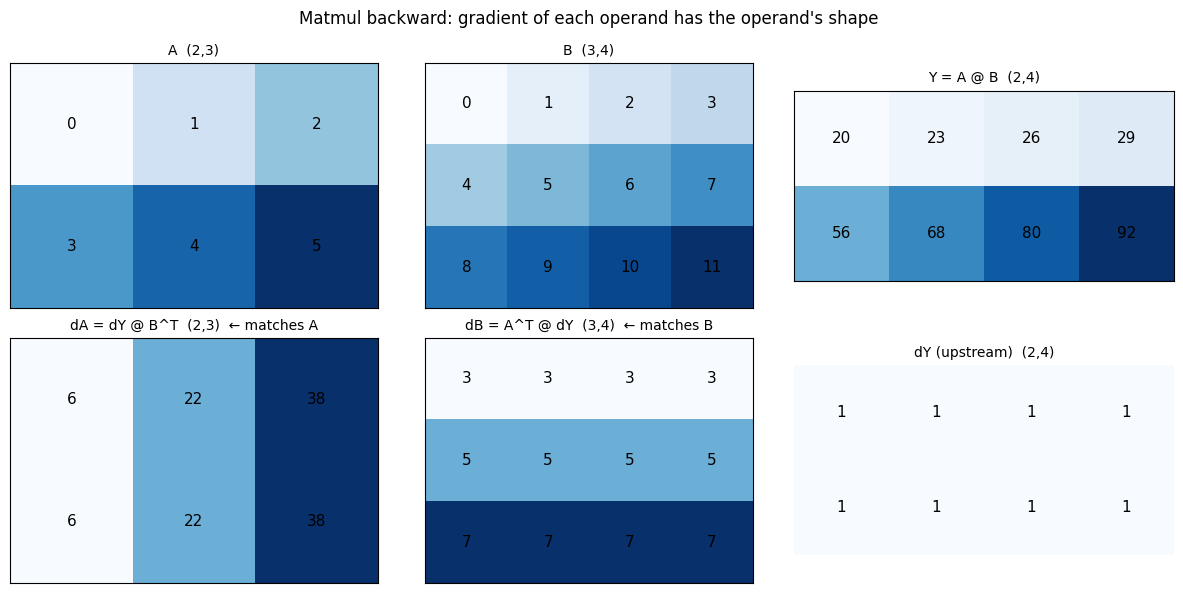

In [7]:
A = np.arange(6).reshape(2, 3).astype(float)
B = np.arange(12).reshape(3, 4).astype(float)
Y = A @ B
gY = np.ones_like(Y)
dA = gY @ B.T
dB = A.T @ gY

fig, ax = plt.subplots(2, 3, figsize=(12, 6))
show(ax[0, 0], A,  "A  (2,3)")
show(ax[0, 1], B,  "B  (3,4)")
show(ax[0, 2], Y,  "Y = A @ B  (2,4)")
show(ax[1, 0], dA, "dA = dY @ B^T  (2,3)  ← matches A")
show(ax[1, 1], dB, "dB = A^T @ dY  (3,4)  ← matches B")
ax[1, 2].axis("off")
show(ax[1, 2], gY, "dY (upstream)  (2,4)")
fig.suptitle("Matmul backward: gradient of each operand has the operand's shape", fontsize=12)
plt.tight_layout(); plt.show()


## 5. Reductions, nonlinearity, and the backward pass

We still need: **sum/mean** (to turn a batch of losses into one scalar), **ReLU** (nonlinearity), and **exp/log** (for cross-entropy). Reductions are the mirror image of broadcasting: the forward *collapses* an axis, so the backward *broadcasts* the gradient back out over that axis.

Then the `backward()` driver is **identical to Notebook 1** — topological sort, seed the output grad, walk in reverse. The only change: the seed is `np.ones_like` instead of the scalar `1.0` (and we require the output to be a scalar, as every loss is).


In [8]:
def _sum(self, axis=None, keepdims=False):
    out = Tensor(self.data.sum(axis=axis, keepdims=keepdims), (self,), 'sum')
    def _backward():
        g = out.grad
        if axis is not None and not keepdims:
            g = np.expand_dims(g, axis)          # restore the collapsed axis
        self.grad += np.ones_like(self.data) * g # then broadcast back to full shape
    out._backward = _backward
    return out

def _mean(self, axis=None, keepdims=False):
    n = self.data.size if axis is None else self.data.shape[axis]
    return self.sum(axis=axis, keepdims=keepdims) * (1.0 / n)

def _relu(self):
    out = Tensor(np.maximum(0.0, self.data), (self,), 'relu')
    def _backward():
        self.grad += (self.data > 0) * out.grad   # gate: pass grad where active
    out._backward = _backward
    return out

def _exp(self):
    out = Tensor(np.exp(self.data), (self,), 'exp')
    def _backward(): self.grad += out.data * out.grad
    out._backward = _backward
    return out

def _log(self):
    out = Tensor(np.log(self.data), (self,), 'log')
    def _backward(): self.grad += (1.0 / self.data) * out.grad
    out._backward = _backward
    return out

def _backward_driver(self):
    topo, visited = [], set()
    def build(v):
        if v not in visited:
            visited.add(v)
            for ch in v._prev: build(ch)
            topo.append(v)
    build(self)
    self.grad = np.ones_like(self.data)   # dL/dL = 1, at the output's shape (scalar)
    for node in reversed(topo):
        node._backward()

for name, fn in [('sum', _sum), ('mean', _mean), ('relu', _relu),
                 ('exp', _exp), ('log', _log), ('backward', _backward_driver)]:
    setattr(Tensor, name, fn)
print("reductions, relu, exp/log, and backward() attached")


reductions, relu, exp/log, and backward() attached


## 6. Softmax cross-entropy and the `p − y` gradient

For classification we need to turn logits into a loss. Softmax turns logits $z$ into probabilities $p_i = \dfrac{e^{z_i}}{\sum_j e^{z_j}}$, and cross-entropy loss for the true class $t$ is $L = -\log p_t$.

The magic result — worth remembering for interviews — is that the gradient of softmax-cross-entropy w.r.t. the **logits** collapses to something stunningly simple:

$$\frac{\partial L}{\partial z_i} = p_i - \mathbb{1}[i = t] \;=\; p - y_{\text{onehot}}.$$

"Predicted probability minus the truth." Let's earn that result — it looks like magic, but it's two clean chain-rule steps.

**Step 1 — derivative of softmax.** With $p_i = e^{z_i}/\sum_j e^{z_j}$, differentiate one probability w.r.t. one logit. There are two cases (this is the standard softmax Jacobian):
$$\frac{\partial p_i}{\partial z_k} = \begin{cases} p_i(1 - p_i) & i = k \\ -\,p_i\,p_k & i \ne k \end{cases} \quad=\quad p_i(\delta_{ik} - p_k),$$
where $\delta_{ik}$ is 1 if $i=k$ else 0. (The $i=k$ case is the quotient rule on $e^{z_i}/\Sigma$; the $i\ne k$ case is because $z_k$ only appears in the denominator $\Sigma$.)

**Step 2 — chain through the loss.** The loss is $L = -\log p_t$ for the true class $t$, so $\dfrac{\partial L}{\partial p_i} = -\dfrac{1}{p_t}$ but *only for $i=t$* (the loss only looks at the true-class probability). Chain it onto the softmax Jacobian, summing over the class index $i$:
$$\frac{\partial L}{\partial z_k} = \sum_i \frac{\partial L}{\partial p_i}\frac{\partial p_i}{\partial z_k} = -\frac{1}{p_t}\cdot\frac{\partial p_t}{\partial z_k} = -\frac{1}{p_t}\,p_t(\delta_{tk} - p_k) = p_k - \delta_{tk}.$$
The $1/p_t$ and $p_t$ cancel — that's the "magic." Reading $\delta_{tk}$ as the one-hot label $y$, we land on
$$\boxed{\dfrac{\partial L}{\partial z} = p - y}.$$

**Why this matters practically.** All the messy $\exp$/$\log$/division derivatives telescope into a single subtraction. So we implement cross-entropy directly (with the standard max-subtraction for numerical stability) and give it this hand-written `p - y` backward, rather than composing it from `exp`/`log`/`sum`. It's faster, more numerically stable, and it's exactly what PyTorch's fused `cross_entropy` does under the hood.


In [9]:
def cross_entropy(logits, targets):
    """logits: Tensor (N, C).  targets: int array (N,).  Returns scalar-loss Tensor."""
    z = logits.data
    z = z - z.max(axis=1, keepdims=True)              # stability shift (does not change softmax)
    ez = np.exp(z)
    probs = ez / ez.sum(axis=1, keepdims=True)        # softmax, shape (N, C)
    N = z.shape[0]
    loss_val = -np.log(probs[np.arange(N), targets] + 1e-12).mean()
    out = Tensor(loss_val, (logits,), 'cross_entropy')
    def _backward():
        grad = probs.copy()                            # p
        grad[np.arange(N), targets] -= 1.0             # p - y_onehot
        grad /= N                                      # because we averaged over the batch
        logits.grad += grad * out.grad
    out._backward = _backward
    return out

print("cross_entropy attached")


cross_entropy attached


## 7. Gradient check (numerical)

Same discipline as before: perturb each input element by ±h, measure the change in a scalar loss, compare to the analytic gradient. We test an expression that uses **matmul + broadcast-add + relu + sum** together — the full stack.


In [10]:
def numeric_grad(f, x, h=1e-6):
    """Central-difference gradient of scalar f w.r.t. every element of array x."""
    g = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old = x[idx]
        x[idx] = old + h; fp = f(x)
        x[idx] = old - h; fm = f(x)
        x[idx] = old
        g[idx] = (fp - fm) / (2 * h)
        it.iternext()
    return g

np.random.seed(0)
A0 = np.random.randn(4, 5)
W0 = np.random.randn(5, 3)
b0 = np.random.randn(3)

def forward_scalar(A_, W_, b_):
    A, W, b = Tensor(A_), Tensor(W_), Tensor(b_)
    L = (A @ W + b).relu().sum()      # (4,3) -> relu -> scalar
    return A, W, b, L

A, W, b, L = forward_scalar(A0, W0, b0)
L.backward()

# numeric grads (vary one input array at a time, hold others fixed)
gA = numeric_grad(lambda x: forward_scalar(x, W0, b0)[3].data, A0.copy())
gW = numeric_grad(lambda x: forward_scalar(A0, x, b0)[3].data, W0.copy())
gb = numeric_grad(lambda x: forward_scalar(A0, W0, x)[3].data, b0.copy())

for name, ours, num in [('A', A.grad, gA), ('W', W.grad, gW), ('b', b.grad, gb)]:
    err = np.abs(ours - num).max()
    print(f"{name}: max abs err vs numeric = {err:.2e}")
assert max(np.abs(A.grad-gA).max(), np.abs(W.grad-gW).max(), np.abs(b.grad-gb).max()) < 1e-5
print("\n✅ tensor gradient check passed")


A: max abs err vs numeric = 2.00e-09
W: max abs err vs numeric = 1.70e-09
b: max abs err vs numeric = 1.50e-09

✅ tensor gradient check passed


## 8. Verify against PyTorch

The real trust test. We rebuild the *same* computations in PyTorch and confirm every gradient matches — including the cross-entropy `p − y` gradient against `torch.nn.functional.cross_entropy`.


In [11]:
import torch
import torch.nn.functional as F

# --- (a) matmul + broadcast-add + relu + sum ---
An, Wn, bn = np.random.randn(4, 5), np.random.randn(5, 3), np.random.randn(3)
A, W, b = Tensor(An), Tensor(Wn), Tensor(bn)
((A @ W + b).relu().sum()).backward()

At = torch.tensor(An, requires_grad=True)
Wt = torch.tensor(Wn, requires_grad=True)
bt = torch.tensor(bn, requires_grad=True)
((At @ Wt + bt).relu().sum()).backward()

print("A grad match:", np.allclose(A.grad, At.grad.numpy(), atol=1e-9))
print("W grad match:", np.allclose(W.grad, Wt.grad.numpy(), atol=1e-9))
print("b grad match:", np.allclose(b.grad, bt.grad.numpy(), atol=1e-9))

# --- (b) softmax cross-entropy gradient ---
logits_np = np.random.randn(6, 4)
targets   = np.array([0, 3, 1, 2, 0, 1])
lt = Tensor(logits_np); cross_entropy(lt, targets).backward()

logits_t = torch.tensor(logits_np, requires_grad=True)
F.cross_entropy(logits_t, torch.tensor(targets, dtype=torch.long)).backward()

print("cross-entropy grad match:", np.allclose(lt.grad, logits_t.grad.numpy(), atol=1e-9))
assert np.allclose(lt.grad, logits_t.grad.numpy(), atol=1e-9)
print("\n✅ matches PyTorch")


A grad match: True
W grad match: True
b grad match: True
cross-entropy grad match: True

✅ matches PyTorch


## 9. A `Linear` layer and an `MLP`

With the engine done, layers are trivial — a `Linear` is just `x @ W + b`. Note the bias `(nout,)` broadcasts over the batch, and `unbroadcast` sums its gradient back over the batch automatically. We use **Kaiming/He init** (`std = sqrt(2/nin)`) so signal variance is preserved through ReLUs — you'll derive this properly in the init/normalization notebook; for now, take it as "the scaling that keeps deep ReLU nets from dying."


In [12]:
class Linear:
    def __init__(self, nin, nout):
        self.W = Tensor(np.random.randn(nin, nout) * np.sqrt(2.0 / nin))
        self.b = Tensor(np.zeros(nout))
    def __call__(self, x):  return x @ self.W + self.b
    def parameters(self):   return [self.W, self.b]

class MLP:
    def __init__(self, sizes):
        self.layers = [Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
    def __call__(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:      # ReLU on all but the last (logit) layer
                x = x.relu()
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

print("Linear + MLP defined")


Linear + MLP defined


## 10. The dataset: two interleaving moons

A classic **not linearly separable** toy problem — no straight line splits the two classes, so the model *must* use its hidden layer + nonlinearity. (Generated with NumPy, no scikit-learn.)


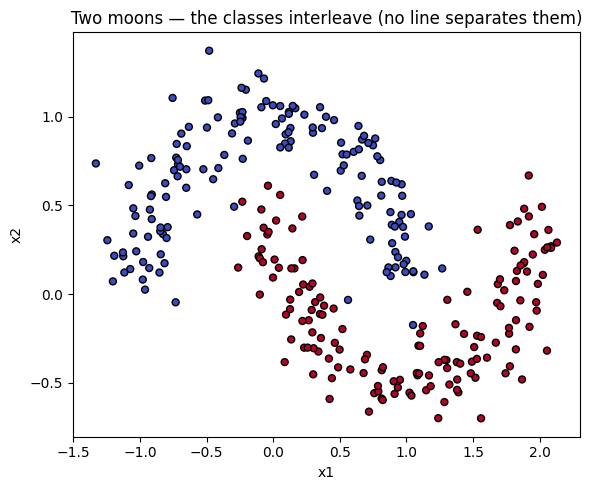

In [13]:
def make_moons(n=300, noise=0.15, seed=1):
    rng = np.random.default_rng(seed)
    n2 = n // 2
    t = np.linspace(0, np.pi, n2)
    upper = np.stack([np.cos(t),          np.sin(t)],        axis=1)
    lower = np.stack([1 - np.cos(t), 0.5 - np.sin(t)],       axis=1)
    X = np.concatenate([upper, lower]) + noise * rng.standard_normal((n, 2))
    y = np.array([0] * n2 + [1] * n2)
    return X, y

X, y = make_moons()
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=25)
plt.title("Two moons — the classes interleave (no line separates them)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()


## 11. Decision boundary *before* training

Let's define a boundary-plotting helper and look at the model **before** any training — a fresh, random net. The colored regions show which class the model predicts across the plane. It should look random/useless right now.


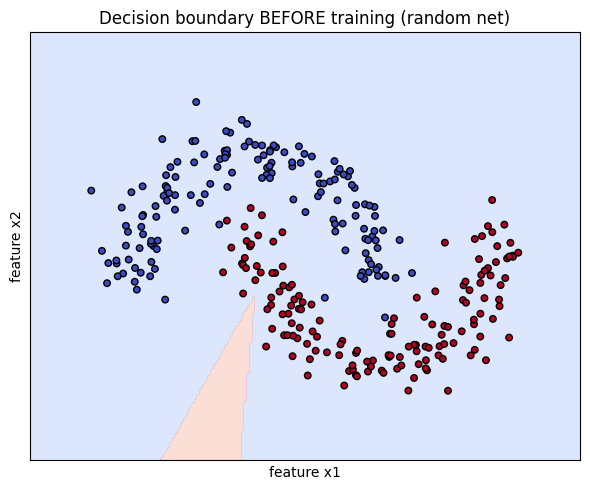

In [14]:
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model(Tensor(grid)).data.argmax(1).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=1, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=22)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("feature x1"); ax.set_ylabel("feature x2")

np.random.seed(42)
model = MLP([2, 16, 16, 2])            # 2 inputs -> 2 hidden layers -> 2 logits
fig, ax = plt.subplots(figsize=(6, 5))
plot_boundary(ax, model, X, y, "Decision boundary BEFORE training (random net)")
plt.tight_layout(); plt.show()


## 12. Train it — full-batch gradient descent

The loop is the same four steps as Notebook 1, now over tensors. Only leaf **parameters** need `zero_grad` each step (intermediate tensors are rebuilt every forward pass, so their grads start fresh). We record the loss to plot the curve.


In [15]:
Xt = Tensor(X)                          # inputs don't change; grad on them is unused
lr = 0.5
losses = []
for step in range(400):
    logits = model(Xt)                  # forward: (N, 2)
    loss = cross_entropy(logits, y)     # scalar
    for p in model.parameters():        # zero_grad (only the params)
        p.grad = np.zeros_like(p.data)
    loss.backward()                     # fill every p.grad
    for p in model.parameters():        # SGD update
        p.data -= lr * p.grad
    losses.append(loss.data.item())
    if step % 50 == 0 or step == 399:
        acc = (model(Xt).data.argmax(1) == y).mean()
        print(f"step {step:3d}   loss {loss.data.item():.4f}   train acc {acc:.3f}")


step   0   loss 0.7874   train acc 0.853
step  50   loss 0.1767   train acc 0.927
step 100   loss 0.0873   train acc 0.977
step 150   loss 0.0427   train acc 0.990


step 200   loss 0.0275   train acc 0.993
step 250   loss 0.0213   train acc 0.993
step 300   loss 0.0180   train acc 0.993
step 350   loss 0.0157   train acc 0.997
step 399   loss 0.0140   train acc 1.000


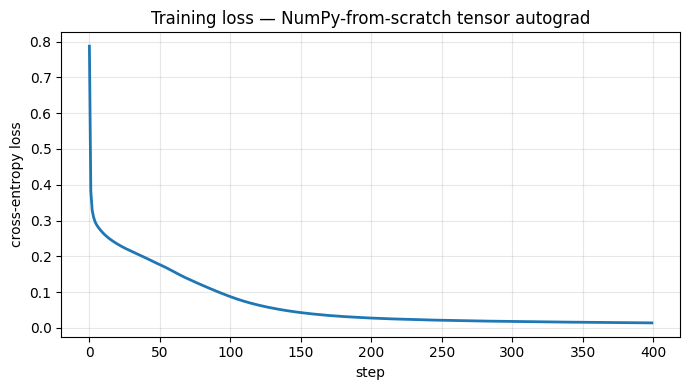

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(losses, lw=2)
plt.xlabel("step"); plt.ylabel("cross-entropy loss")
plt.title("Training loss — NumPy-from-scratch tensor autograd")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 13. Decision boundary *after* training

Same model, now trained. The boundary should curve to follow the two moons — something a linear model could never do. Side-by-side proof that your from-scratch engine learned a nonlinear function.


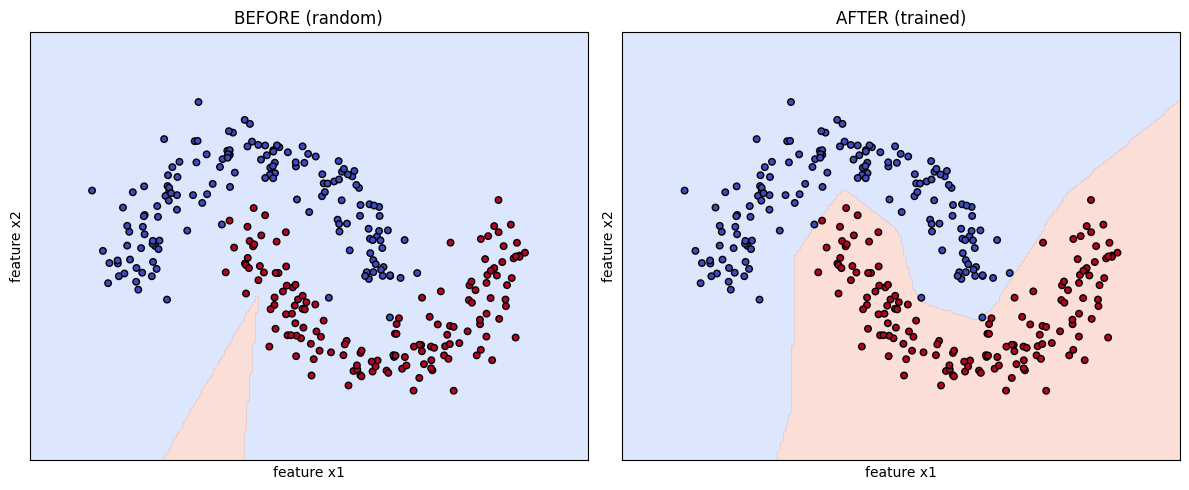

final train accuracy: 1.000


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
np.random.seed(42); fresh = MLP([2, 16, 16, 2])
plot_boundary(ax[0], fresh, X, y, "BEFORE (random)")
plot_boundary(ax[1], model, X, y, "AFTER (trained)")
plt.tight_layout(); plt.show()

final_acc = (model(Tensor(X)).data.argmax(1) == y).mean()
print(f"final train accuracy: {final_acc:.3f}")


**What to notice.** Look at the shape of the two boundaries. *Before* training, the colored regions are split by an essentially straight, randomly-oriented line — a fresh net with random weights is basically a linear classifier, and a line cannot separate two interleaving moons (the best it could do is ~75–80% and it's not even trying yet). *After* training, the boundary **curves** — it wraps around the top moon and dips under the bottom one, threading between the classes.

That curvature is the whole point of a hidden layer + nonlinearity. Each `Linear` layer can only draw straight lines; it's the **ReLU** between them that lets the network bend and fold those lines into a curved decision surface. Strip out the ReLU (make the MLP `Linear → Linear`) and it collapses back to a single linear map — try it (Exercise 6's cousin) and you'll watch the boundary snap back to a straight line and the accuracy fall. **The nonlinearity is not a detail; it is the source of the model's expressive power.** You just demonstrated that from scratch.


## 14. What you built

You upgraded scalar autodiff to **tensor autodiff**: a `Tensor` node holding a NumPy array, the **`unbroadcast`** rule that reverses broadcasting by summing over stretched axes, the **matrix chain rule** for `@` (`dA = dY·Bᵀ`, `dB = Aᵀ·dY`, pinned down by shape-matching), reductions as the mirror of broadcasting, and the **softmax-cross-entropy `p − y`** gradient. On top of it you built `Linear`/`MLP` and trained a nonlinear classifier that bends its decision boundary around two moons — all in pure NumPy, all matching PyTorch to ~1e-9.

This engine is the template every framework follows. From here on we can *use* tensor autograd (yours or PyTorch's — they agree) and focus on the ideas layered on top.

## 15. Exercises
1. **Add `tanh` and `sigmoid`** as `Tensor` methods; gradient-check them.
2. **Minibatching.** Change training to sample minibatches instead of full-batch. Does the loss curve get noisier? Why?
3. **The bias-gradient question.** Print `model.layers[0].b.grad.shape` mid-training and explain in one sentence why it's `(16,)` and not `(N,16)` — name the function responsible.
4. **Break `unbroadcast`.** Remove step (a) (the leading-dims sum) and find an op whose gradient now crashes with a shape error. Explain.
5. **Batched matmul.** Feed a 3-D input `(batch, N, K)` through a `@` and confirm the `swapaxes(-1,-2)` backward still matches PyTorch.
6. **Weight-init ablation.** Re-init `Linear` with `np.random.randn(...) * 0.01` instead of He init. Train the moons MLP and compare loss curves — what happens to learning, and why? (Preview of the init notebook.)

## 16. Interview / residency framing
- *"How does a gradient flow back through broadcasting?"* → sum over the broadcasted (stretched) axes; reuse ⇒ sum (multivariate chain rule). That's `unbroadcast`.
- *"Derive the backward of `Y = A @ B`."* → `dA = dY Bᵀ`, `dB = Aᵀ dY`; justify by shape-matching (grad of X has X's shape).
- *"Why is the softmax-cross-entropy gradient just `p − y`?"* → the log and softmax Jacobians telescope; know how to sketch it. It's why we fuse the two ops.
- *"Why sum bias gradients over the batch?"* → the bias is broadcast across the batch dimension, so its gradient is summed back over it.
- *"Where does this still fall short of PyTorch?"* → no GPU, no fused kernels, no in-place ops, recomputes graphs in Python; but the *math* is identical. Next we go deeper on the pieces: **layers, init/normalization, and optimizers.**

---
**Next:** *Tier 0 · Notebook 3 — Backprop through the classic layers* (Linear, BatchNorm/LayerNorm, Conv2d, softmax) each with a hand-derived, gradient-checked backward.


## 📚 References & papers

This notebook reproduces / builds on:

- **PyTorch: An Imperative Style, High-Performance Deep Learning Library** — Paszke et al. (2019), NeurIPS. The tensor-autograd system we verify against.
- **Learning representations by back-propagating errors** — Rumelhart, Hinton & Williams (1986). Backprop / the chain rule.